In [4]:
import PKA_Sleep as PKA
import numpy as np
import matplotlib.pyplot as plt
import os
from neuroscience_sleep_scoring import SWS_utils
from PKA_Sleep import Graphing_Utils as graph
from scipy import stats
import pandas as pd
graph.make_bigandbold()

In [1]:
parent_data_directory = '/Volumes/yaochen/Active/Lizzie/FLP_data/'
experiment_names = ['ltFLiPAKARmemEEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0010',
                    'dgFLiPmemAKAREEGEMG0003',
                    'dgFLiPmemAKAREEGEMG0008',
                    'ltFLiPAKARmemEEGEMG0036',
                    'ltFLiPAKARmemEEGEMG0043',
                    'kgFLiPAKAREEGEMG0009',
                    'ltFLiPAKARmemEEGEMG0055',
                    'ltFLiPAKARmemEEGEMG0068',
                    'ltFLiPAKARmemEEGEMG0072',
                    'ltFLiPAKARmemEEGEMG0085',
                    'ltFLiPAKARmemEEGEMG0090-1',
                    'ltFLiPAKARmemEEGEMG0094',
                    'ltFLiPAKARmemEEGEMG0097-1',
                    'ltFLiPAKARmemEEGEMG0098-1',
                    'ltFLiPAKARmemEEGEMG0099-1',
                    'ltFLiPAKARmemEEGEMG0099-2',
                    'ltFLiPAKARmemEEGEMG0100-1',
                    'ltFLiPAKARmemEEGEMG0101-1',
                    'ltFLiPAKARmemEEGEMG0102-1',
                    'ltFLiPAKARmemEEGEMG0103-1',
                    'kgFLiPAKAREEGEMG0018',
                    'kgFLiPAKAREEGEMG0019',
                    'kgFLiPAKAREEGEMG0020']
mouse_names = ['3825',
                '3825',
                '3825',
                '3825',
                '4346-t5-7',
                '4346-t5-7',
                '4507',
                '4502',
                '4507',
                '4610',
                '4713',
                '4769',
                '4775',
                '5782',
                '5007',
                '5075',
                '5075',
                '5078',
                '5046',
                '5047',
                '5076',
                '5582',
                '5583',
                '5577']
df = pd.read_excel('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/FLiP_Experiment_Summary.xlsx')
raw_datadirs = [os.path.join(parent_data_directory, e) for e in experiment_names]

baseline_idxs = [(int(d['Baseline Start'].values),int(d['Baseline End'].values)) 
                  for d in [df.loc[df['Experiment Name'] == e] for e in experiment_names]]
excluded_acqs = PKA.choose_excluded_acqs(raw_datadirs, first_acqs = 3, specific_acqs = False, 
                                              pull_baseline = True, baseline_idxs = baseline_idxs)
# Set FLiP class parameters and build classes
epoch_len = 4
filter_bounds = [None, None]
binned = False
shuffle_window = 100
experimental_sensor = 'FLIM-mAKAR'
sleep_states = False
microarousals = True
seperate_acqs = False
shuffled = True
FLP_classes_dict = PKA.build_classes(experiment_names, mouse_names, epoch_len = epoch_len, 
                                     filter_bounds = filter_bounds, binned = binned, 
                                     shuffle_window = shuffle_window, experimental_sensor = experimental_sensor, 
                                     sleep_states = sleep_states, microarousals = microarousals, 
                                     seperate_acqs = seperate_acqs, emp_lifetime = False,
                                     parent_data_directory = parent_data_directory, gather_timestamps = True, 
                                     exclude_acqs = excluded_acqs)

NameError: name 'pd' is not defined

In [3]:
freq_dict = {'Delta':[0.5, 4], 
             'Theta':[4,8] , 
             'Sigma':[10,15], 
             'Beta':[15,30]}
mutual_information = {'chan0': {k:[] for k in freq_dict.keys()}, 'chan2': {k:[] for k in freq_dict.keys()}}
grouped_experiments = {a:{'Experiment Classes':[FLP_classes_dict['Experiment Classes'][i] 
                                                for i in range(len(FLP_classes_dict['Experiment Classes'])) 
                                                               if str(FLP_classes_dict['Animal Names'][i]) == a],
                         'Experiment Names':[FLP_classes_dict['Experiment Names'][i] 
                                                for i in range(len(FLP_classes_dict['Experiment Names'])) 
                                                               if str(FLP_classes_dict['Animal Names'][i]) == a],
                         'Mutual Information Data': {k1: {k2: [] for k2 in freq_dict.keys()} for k1 in mutual_information.keys()}}
                       for a in np.unique(FLP_classes_dict['Animal Names'])}
for a in grouped_experiments.keys():
    for b, FLP_exp in zip(grouped_experiments[a]['Experiment Names'], grouped_experiments[a]['Experiment Classes']):
        for chan in [0,2]:
            FLP_exp.add_EEG(downsamp_EEG = True, get_EMG = False, chan = chan)
            power_dict = SWS_utils.bandPower(FLP_exp.EEG, 200, freq_dict = freq_dict, minfreq = 0.5, maxfreq = 40, window_length = 10, 
                noverlap = 9, window_type = None)
            t = FLP_exp.Time-FLP_exp.Time[0]
            timerange_idx, = np.where((t >= power_dict['Bins'][0]-1) & (t <= power_dict['Bins'][-1]+1))
            
            lft = PKA.interpolate_photometry(FLP_exp.Lifetime[timerange_idx], t[timerange_idx], power_dict['Bins'])
            mutual_information['chan'+str(chan)] = {k: PKA.nlcc_mi(power_dict[k], lft, max_lag = 250, num_bins = 100) 
                                                    for k in power_dict.keys()}
        for k1 in mutual_information.keys():
            for k2 in freq_dict.keys():
                grouped_experiments[a]['Mutual Information Data'][k1][k2].append(mutual_information[k1][k2])
    grouped_experiments[a]['Animal Average'] = {k1: {k2: 
                                                     np.mean([grouped_experiments[a]['Mutual Information Data'][k1][k2][i][0] 
                                             for i in range(len(grouped_experiments[a]['Mutual Information Data'][k1][k2]))], 
                                                             axis = 0) for k2 in freq_dict.keys()} for k1 in mutual_information.keys()} 

/Volumes/yaochen/Active/Lizzie/FLP_data/ltFLiPAKARmemEEGEMG0009/ltFLiPAKARmemEEGEMG0009_extracted_data/AD0_downsampled
Calculating Delta Band Power...
Calculating Theta Band Power...
Calculating Sigma Band Power...
Calculating Beta Band Power...
/Volumes/yaochen/Active/Lizzie/FLP_data/ltFLiPAKARmemEEGEMG0009/ltFLiPAKARmemEEGEMG0009_extracted_data/AD2_downsampled
Calculating Delta Band Power...
Calculating Theta Band Power...
Calculating Sigma Band Power...
Calculating Beta Band Power...
/Volumes/yaochen/Active/Lizzie/FLP_data/ltFLiPAKARmemEEGEMG0010/ltFLiPAKARmemEEGEMG0010_extracted_data/AD0_downsampled
Calculating Delta Band Power...
Calculating Theta Band Power...
Calculating Sigma Band Power...
Calculating Beta Band Power...
/Volumes/yaochen/Active/Lizzie/FLP_data/ltFLiPAKARmemEEGEMG0010/ltFLiPAKARmemEEGEMG0010_extracted_data/AD2_downsampled
Calculating Delta Band Power...
Calculating Theta Band Power...
Calculating Sigma Band Power...
Calculating Beta Band Power...
/Volumes/yaochen

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


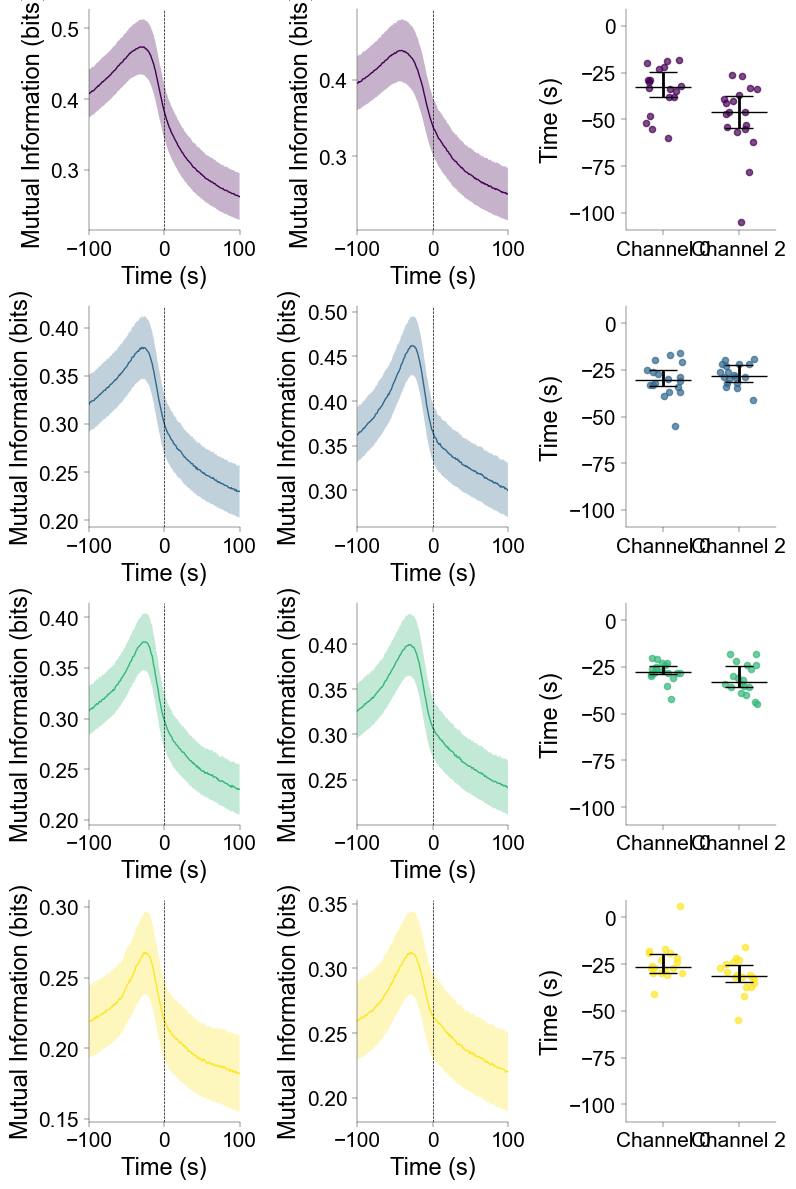

In [4]:
fig_savedir = '/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_2/'
fig, ax = plt.subplots(ncols = 3, nrows = len(freq_dict.keys()), figsize = [8,12])
color_list = graph.get_colormap(len(freq_dict.keys()))
window = [-100, 100]
pvals = {'chan0':{}, 'chan2':{}}
for col, k1 in enumerate(grouped_experiments[list(grouped_experiments.keys())[0]]['Animal Average'].keys()):
    for row,k2 in enumerate(freq_dict.keys()):
        y_trace = np.mean([grouped_experiments[a]['Animal Average'][k1][k2] for a in grouped_experiments.keys()], axis = 0)
        x = grouped_experiments[list(grouped_experiments.keys())[0]]['Mutual Information Data'][k1][k2][0][1]
        error = stats.sem([grouped_experiments[a]['Animal Average'][k1][k2] for a in grouped_experiments.keys()], axis = 0)
        graph.linegraph_w_error(ax[row,col], x[(x>=window[0])&(x<=window[1])],y_trace[(x>=window[0])&(x<=window[1])], 
                                error[(x>=window[0])&(x<=window[1])], color = color_list[row], label = None, linewidth = 1, 
                                linestyle = '-', alpha = 0.3)
        # ax[row,col].axvline(x[np.argmax(y_trace)], color = 'k', linestyle = '--', linewidth = 0.5)
        ax[row,col].axvline(0, color = 'k', linestyle = '--', linewidth = 0.5)
        ax[row,col].set_xlim([window[0], window[-1]])
for row,k2 in enumerate(freq_dict.keys()):
    scatter_vals = [[x[np.argmax(grouped_experiments[a]['Animal Average']['chan0'][k2])] for a in grouped_experiments.keys()], 
                    [x[np.argmax(grouped_experiments[a]['Animal Average']['chan2'][k2])] for a in grouped_experiments.keys()]]
    pvals['chan0'][k2] = stats.wilcoxon(scatter_vals[0])
    pvals['chan2'][k2] = stats.wilcoxon(scatter_vals[1])
    x_centers = [0,1]
    colors = [color_list[row], color_list[row]]
    graph.swarm_plot(fig, ax[row, 2], scatter_vals, x_centers, colors, edgecolors=None, x_width=0.25, avg_type='median', 
                     percentiles=[25, 75], x_labels=['Channel 0', 'Channel 2'], ylabel=None, capsize=10, markersize=40, alpha=0.7, 
                     scatter_size=20, match_ebarcolor=False, legend_labels=None)
    ax[row, 2].set_xlim([-0.5, 1.5])
graph.thick_axes(fig, ax, width = 0.3)
graph.match_yaxes(ax[:,2])
for a in np.concatenate(ax[:, :2]):
    graph.label_axes(a, x = 'Time (s)', y = 'Mutual Information (bits)')
for a in ax[:,2]:
    graph.label_axes(a, y = 'Time (s)')
fig.tight_layout()
fig.savefig(os.path.join(fig_savedir, 'mutual_information_mPFC.ps'))

In [5]:
pvals

{'chan0': {'Delta': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019575042504300203)),
  'Theta': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019575042504300203)),
  'Sigma': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019234537760844035)),
  'Beta': WilcoxonResult(statistic=np.float64(1.0), pvalue=np.float64(0.00022965868177333754))},
 'chan2': {'Delta': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019609335453373022)),
  'Theta': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019302286813915962)),
  'Sigma': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019506589130048005)),
  'Beta': WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.00019438312233538687))}}

In [5]:
len(np.unique(mouse_names))

18